In [1]:
from scipy.io import loadmat
import numpy as np
import pandas as pd

hn = loadmat("data/hn.mat", simplify_cells=True)
rd = loadmat("data/rd.mat", simplify_cells=True)

print("hn.mat variables:", [k for k in hn if not k.startswith("__")])
print("rd.mat variables:", [k for k in rd if not k.startswith("__")])

hn.mat variables: ['HMD_data']
rd.mat variables: ['QPtoR_exp', 'QPtoR_pow', 'RtoD_exp', 'RtoD_pow', 'video_bitrate_data', 'video_ymse_data']


In [2]:
def summarize(data):
    rows = []

    for name, value in data.items():
        if not name.startswith("__"):
            rows.append({
                "variable": name,
                "type": type(value).__name__,
                "shape": getattr(value, "shape", None),
                "dtype": getattr(value, "dtype", None)
            })

    return pd.DataFrame(rows)

display(summarize(hn))
display(summarize(rd))

,variable,type,shape,dtype
0,HMD_data,ndarray,"(15, 34)",object


,variable,type,shape,dtype
0,QPtoR_exp,ndarray,"(15, 64, 36)",object
1,QPtoR_pow,ndarray,"(15, 64, 36)",object
2,RtoD_exp,ndarray,"(15, 64, 36)",object
3,RtoD_pow,ndarray,"(15, 64, 36)",object
4,video_bitrate_data,ndarray,"(15,)",object
5,video_ymse_data,ndarray,"(15,)",object


In [3]:
HMD_data = hn["HMD_data"]

print("Type:", type(HMD_data))
print("Shape:", getattr(HMD_data, "shape", None))

HMD_data

Type: <class 'numpy.ndarray'>
Shape: (15, 34)


array([[array([[-4.87472000e+01, -7.43252000e+00,  3.84284000e+00,
                 5.70000000e-07],
               [-1.90194000e-04, -3.71622307e+00,  1.92141506e+00,
                 3.50078600e-02],
               [-1.34120000e-03, -3.71570267e+00,  1.92129903e+00,
                 6.72867500e-02],
               ...,
               [ 2.57721000e+00,  4.09246400e+01, -2.22518800e+01,
                 3.59003695e+01],
               [ 3.68045000e+00,  4.08460400e+01, -2.16060800e+01,
                 3.59352382e+01],
               [ 4.57137000e+00,  4.07812400e+01, -2.10942800e+01,
                 3.59676810e+01]], shape=(1080, 4))               ,
        array([[-1.20211000e+02, -1.39038600e+01,  2.03456000e+01,
                 5.70000000e-07],
               [ 2.70844000e-14, -6.95186235e+00,  1.01732130e+01,
                 3.33759530e-02],
               [-1.24072000e-04, -6.95155949e+00,  1.01746957e+01,
                 6.80066330e-02],
               ...,
               [ 

In [4]:
for name in ["QPtoR_exp", "QPtoR_pow", "RtoD_exp", "RtoD_pow"]:
    array = rd[name]

    nonempty = [
        index
        for index in np.ndindex(array.shape)
        if np.asarray(array[index]).size > 0
    ]

    print(f"{name}:")
    print("  Shape:", array.shape)
    print("  Nonempty cells:", len(nonempty))
    print("  First indices:", nonempty[:5])

QPtoR_exp:
  Shape: (15, 64, 36)
  Nonempty cells: 24576
  First indices: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4)]
QPtoR_pow:
  Shape: (15, 64, 36)
  Nonempty cells: 24576
  First indices: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4)]
RtoD_exp:
  Shape: (15, 64, 36)
  Nonempty cells: 24576
  First indices: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4)]
RtoD_pow:
  Shape: (15, 64, 36)
  Nonempty cells: 24576
  First indices: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4)]


In [5]:
variable = rd["QPtoR_exp"]

nonempty = [
    index
    for index in np.ndindex(variable.shape)
    if np.asarray(variable[index]).size > 0
]

if nonempty:
    index = nonempty[0]
    print("Index:", index)
    display(variable[index])
else:
    print("Every cell in QPtoR_exp is empty.")
    

Index: (0, 0, 0)


MatlabOpaque([(b'', b'MCOS', b'cfit', array([3707764736,          2,          1,          1,          1,
                              1], dtype=uint32))                                                        ],
             dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')])

In [6]:
import numpy as np
import pandas as pd

HMD_data = hn["HMD_data"]

# Find all recordings that contain data
hmd_indices = [
    index for index in np.ndindex(HMD_data.shape)
    if np.asarray(HMD_data[index]).size > 0
]

print("Number of recordings:", len(hmd_indices))
print("First recording index:", hmd_indices[0])

recording = np.asarray(HMD_data[hmd_indices[0]])

df_hmd = pd.DataFrame(
    recording,
    columns=["yaw", "pitch", "roll", "timestamp"]
)

display(df_hmd)

Number of recordings: 195
First recording index: (0, 0)


,yaw,pitch,roll,timestamp
0,-48.747200,-7.432520,3.842840,5.700000e-07
1,-0.000190,-3.716223,1.921415,3.500786e-02
2,-0.001341,-3.715703,1.921299,6.728675e-02
3,-0.004152,-3.714361,1.920745,1.025241e-01
4,-0.008139,-3.712591,1.919882,1.371408e-01
...,...,...,...,...
1075,-0.423076,41.028340,-23.829580,3.583335e+01
1076,1.285980,40.994440,-22.961280,3.586785e+01
1077,2.577210,40.924640,-22.251880,3.590037e+01
1078,3.680450,40.846040,-21.606080,3.593524e+01


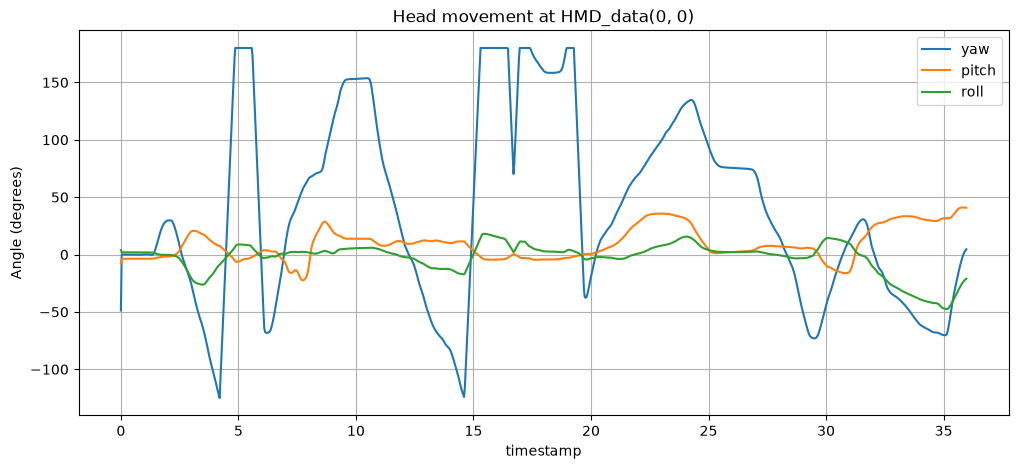

In [7]:
import matplotlib.pyplot as plt

df_hmd.plot(
    x="timestamp",
    y=["yaw", "pitch", "roll"],
    figsize=(12, 5)
)

plt.ylabel("Angle (degrees)")
plt.title(f"Head movement at HMD_data{hmd_indices[0]}")
plt.grid()
plt.show()

## Extended Exploration — What's Actually Available

Cells 1–8 above are the original exploration. Everything below is new and answers three questions for the problem formulation: what's directly **available** in `hn.mat`/`rd.mat`, what's **computable** from them, and what's genuinely **missing**. Nothing below re-loads or duplicates the work above — it reuses `hn`, `rd`, and `HMD_data` as already loaded in cells 1 and 3.

### Section A — Video catalog

Parsed directly from `Readme - Dataset info.txt` at runtime (not retyped) so this table always matches the actual source file. Carries both a 1-based `video_index` (matching the README's "no" column) and a 0-based `array_index` (matching `.mat` array indexing) — mixing these up is an easy off-by-one trap, so every later section joins against `array_index` explicitly.

In [8]:
import re

with open("Readme - Dataset info.txt", "r", encoding="utf-8") as f:
    readme_text = f.read()

rows = []
for line in readme_text.splitlines():
    m = re.match(r"^\s*(\d{1,2})\s*-\s*(.+)$", line)
    if not m:
        continue
    idx_str, rest = m.groups()
    fields = [x.strip() for x in re.split(r"\s*-\s*", rest) if x.strip()]
    if len(fields) != 6:
        continue  # defensively skip anything that doesn't parse cleanly
    name, frames, fps, resolution, depth, projection = fields
    rows.append({
        "video_index": int(idx_str),      # 1-based, matches README's "no" column
        "array_index": int(idx_str) - 1,  # 0-based, matches .mat array indexing
        "name": name,
        "frames": int(frames),
        "fps": int(fps),
        "resolution": resolution,
        "bit_depth": depth,
        "projection": projection,
    })

video_catalog = pd.DataFrame(rows)
assert len(video_catalog) == 15, f"expected 15 videos, parsed {len(video_catalog)} — check regex against readme changes"
display(video_catalog)

,video_index,array_index,name,frames,fps,resolution,bit_depth,projection
0,1,0,Academic,1080,30,8192x4096,8bit,ERP
1,2,1,Basketball,1080,30,8192x4096,8bit,ERP
2,3,2,Bridge,1080,30,8192x4096,8bit,ERP
3,4,3,GateNight,1080,30,8192x4096,8bit,ERP
4,5,4,Runner,1080,30,8192x4096,8bit,ERP
5,6,5,SiyuanGate,1080,30,8192x4096,8bit,ERP
6,7,6,SouthGate,1080,30,8192x4096,8bit,ERP
7,8,7,StudyRoom,1080,30,8192x4096,8bit,ERP
8,9,8,Sward,1080,30,8192x4096,8bit,ERP
9,10,9,Chairlift,300,30,8192x4096,10bit,ERP


### Section B — HMD trace validity and occupancy

`HMD_data` has 510 possible `(video, user)` cells (15×34). Cell 4 above counted non-empty cells across the *rate-distortion* arrays, and cell 7 grabbed the first HMD recording — but neither checks whether a "non-empty" HMD cell is actually real data. At least one cell is a `1080×4` array of **all zeros**: a placeholder, not a recording. To tell real recordings apart:

- `size == 0` → **empty** (nothing stored)
- wrong shape (not `Nx4`) → **unexpected_shape** (defensive fallback; not expected to trigger given the README)
- `np.all(arr == 0)` → **placeholder**. Chosen over checking `dtype == uint8` (a placeholder happening to be stored as uint8 doesn't mean uint8 implies placeholder — that's a coincidence on a single observed case, not a rule) and over `np.allclose(arr, 0)` (a genuine recording can have yaw/pitch/roll samples near zero, but its **timestamp** column strictly increases across up to 1080 rows, so it can never be exactly all-zero). Exact equality is both the more defensible test and, checked directly against this file, sufficient.
- otherwise → **valid**

In [9]:
def classify_hmd_cell(cell):
    arr = np.asarray(cell)
    if arr.size == 0:
        return "empty", arr
    if arr.ndim != 2 or arr.shape[1] != 4:
        return "unexpected_shape", arr
    if np.all(arr == 0):
        return "placeholder", arr
    return "valid", arr

records = []
for idx in np.ndindex(HMD_data.shape):
    status, arr = classify_hmd_cell(HMD_data[idx])
    rec = {
        "array_video_index": idx[0],
        "user_slot": idx[1],
        "status": status,
        "n_rows": arr.shape[0] if arr.size else None,
        "dtype": str(arr.dtype) if arr.size else None,
    }
    if status == "valid":
        ts = arr[:, 3].astype(float)
        rec["duration_sec"] = float(ts.max() - ts.min())
        rec["timestamp_monotonic"] = bool(np.all(np.diff(ts) >= 0))
        rec["ypr_variance_sum"] = float(np.sum(np.var(arr[:, :3].astype(float), axis=0)))
    records.append(rec)

hmd_occupancy = pd.DataFrame(records).merge(
    video_catalog[["array_index", "video_index", "name", "frames"]],
    left_on="array_video_index", right_on="array_index", how="left"
)
hmd_occupancy["matches_frame_count"] = hmd_occupancy["n_rows"] == hmd_occupancy["frames"]
display(hmd_occupancy)

,array_video_index,user_slot,status,n_rows,dtype,duration_sec,timestamp_monotonic,ypr_variance_sum,array_index,video_index,name,frames,matches_frame_count
0,0,0,valid,1080.0,float64,35.967680,True,7099.208265,0,1,Academic,1080,True
1,0,1,valid,1080.0,float64,35.969349,True,8739.467050,0,1,Academic,1080,True
2,0,2,valid,1080.0,float64,35.968094,True,6019.156950,0,1,Academic,1080,True
3,0,3,empty,NaN,NaN,NaN,NaN,NaN,0,1,Academic,1080,False
4,0,4,valid,1080.0,float64,35.970466,True,5678.210710,0,1,Academic,1080,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,14,29,empty,NaN,NaN,NaN,NaN,NaN,14,15,Trolley,300,False
506,14,30,valid,300.0,float64,9.970407,True,7275.246931,14,15,Trolley,300,True
507,14,31,empty,NaN,NaN,NaN,NaN,NaN,14,15,Trolley,300,False
508,14,32,empty,NaN,NaN,NaN,NaN,NaN,14,15,Trolley,300,False


In [10]:
status_counts = hmd_occupancy["status"].value_counts()
print(f"HMD cell status counts (out of {HMD_data.size} total cells):")
print(status_counts)
print()
print(f"README claims HMD_data is 12x12 (144 cells); actual shape is {HMD_data.shape} ({HMD_data.size} cells).")

valid_counts = (
    hmd_occupancy[hmd_occupancy.status == "valid"]
    .groupby("array_index")
    .size()
    .rename("valid_trace_count")
)

per_video = video_catalog[["array_index", "video_index", "name"]].merge(
    valid_counts, on="array_index", how="left"
)
per_video["valid_trace_count"] = per_video["valid_trace_count"].fillna(0).astype(int)
per_video["paper_claimed_min"] = 5
per_video["paper_claimed_max"] = 12
per_video["exceeds_paper_max"] = per_video["valid_trace_count"] > per_video["paper_claimed_max"]
display(per_video)

print(f"Total valid traces: {per_video.valid_trace_count.sum()} vs. paper's claimed total of 121.")
print(f"{int(per_video.exceeds_paper_max.sum())} of {len(per_video)} videos exceed the paper's claimed max of 12 traces/video.")

HMD cell status counts (out of 510 total cells):
status
empty          315
valid          194
placeholder      1
Name: count, dtype: int64

README claims HMD_data is 12x12 (144 cells); actual shape is (15, 34) (510 cells).


,array_index,video_index,name,valid_trace_count,paper_claimed_min,paper_claimed_max,exceeds_paper_max
0,0,1,Academic,12,5,12,False
1,1,2,Basketball,14,5,12,True
2,2,3,Bridge,11,5,12,False
3,3,4,GateNight,17,5,12,True
4,4,5,Runner,12,5,12,False
5,5,6,SiyuanGate,11,5,12,False
6,6,7,SouthGate,14,5,12,True
7,7,8,StudyRoom,12,5,12,False
8,8,9,Sward,12,5,12,False
9,9,10,Chairlift,22,5,12,True


Total valid traces: 194 vs. paper's claimed total of 121.
5 of 15 videos exceed the paper's claimed max of 12 traces/video.


### Section C — Empirical GOP-axis check

The README labels the 3rd axis of `RtoD_exp`/`RtoD_pow`/`QPtoR_exp`/`QPtoR_pow` as `N=frame index`, sized 36. But videos only have 1080 or 300 frames, and 36 doesn't match either directly — 1080/30 = 36 and 300/30 = 10 do, though, which lines up with the paper's stated GOP size of 30 frames (each GOP-tile compressed independently). This section checks that empirically instead of assuming it, and separately confirms `video_bitrate_data`/`video_ymse_data` really are per-*frame* — so the README's "N=frame index" label means two different things for the two variable families.

In [11]:
def nonempty_index_set(arr):
    return {idx for idx in np.ndindex(arr.shape) if np.asarray(arr[idx]).size > 0}

ref_set = nonempty_index_set(rd["RtoD_exp"])
print(f"RtoD_exp nonempty cells: {len(ref_set)}")
for name in ["QPtoR_exp", "QPtoR_pow", "RtoD_pow"]:
    same = nonempty_index_set(rd[name]) == ref_set
    print(f"{name}: identical nonempty-index set to RtoD_exp? {same}")

RtoD_exp nonempty cells: 24576
QPtoR_exp: identical nonempty-index set to RtoD_exp? True
QPtoR_pow: identical nonempty-index set to RtoD_exp? True
RtoD_pow: identical nonempty-index set to RtoD_exp? True


In [12]:
occ_mask = np.array([
    [[np.asarray(rd["RtoD_exp"][v, t, g]).size > 0 for g in range(36)] for t in range(64)]
    for v in range(15)
])  # shape (15, 64, 36)

any_tile = occ_mask.any(axis=1)  # (15, 36): any tile present at this GOP slot?
all_tile = occ_mask.all(axis=1)  # (15, 36): all tiles present at this GOP slot?
uniform_per_video = np.all(any_tile == all_tile, axis=1)  # all-or-none per slot, per video

gop_summary = video_catalog[["array_index", "video_index", "name", "frames"]].copy()
gop_summary["expected_gops"] = np.ceil(gop_summary["frames"] / 30).astype(int)
gop_summary["observed_occupied_gop_slots"] = any_tile.sum(axis=1)
gop_summary["uniform_across_all_64_tiles"] = uniform_per_video
gop_summary["matches_frames_div_30"] = gop_summary["expected_gops"] == gop_summary["observed_occupied_gop_slots"]

display(gop_summary)

for v in [0, 9]:
    shp = np.asarray(rd["video_bitrate_data"][v]).shape
    vname = video_catalog.loc[video_catalog.array_index == v, "name"].iloc[0]
    print(f"video_bitrate_data[{v}] ({vname}) shape = {shp}  <- 3rd axis is frames, NOT GOPs")

,array_index,video_index,name,frames,expected_gops,observed_occupied_gop_slots,uniform_across_all_64_tiles,matches_frames_div_30
0,0,1,Academic,1080,36,36,True,True
1,1,2,Basketball,1080,36,36,True,True
2,2,3,Bridge,1080,36,36,True,True
3,3,4,GateNight,1080,36,36,True,True
4,4,5,Runner,1080,36,36,True,True
5,5,6,SiyuanGate,1080,36,36,True,True
6,6,7,SouthGate,1080,36,36,True,True
7,7,8,StudyRoom,1080,36,36,True,True
8,8,9,Sward,1080,36,36,True,True
9,9,10,Chairlift,300,10,10,True,True


video_bitrate_data[0] (Academic) shape = (7, 64, 1080)  <- 3rd axis is frames, NOT GOPs
video_bitrate_data[9] (Chairlift) shape = (7, 64, 300)  <- 3rd axis is frames, NOT GOPs


### Section D — Real sample rate-distortion numbers

Neither the original exploration nor the occupancy checks above have printed actual bitrate/YMSE numbers. Below is one real, small slice: video 0 (`Academic`), frame 0, tiles 0–7, all 7 QP rows. Row/column labels are deliberately `QP_idx_0..6` and `tile_0..7` rather than literal QP values or grid positions — the dataset confirms 7 QP levels and 64 tiles exist, but the actual QP numbers (paper states 15–35) and the tile grid's 8×8 spatial layout are documented only in the paper, not in these files, so they aren't asserted here as data facts.

In [13]:
video_ix, frame_ix, tile_ixs = 0, 0, list(range(8))

bitrate_sample = rd["video_bitrate_data"][video_ix][:, tile_ixs, frame_ix]
ymse_sample = rd["video_ymse_data"][video_ix][:, tile_ixs, frame_ix]

idx_labels = [f"QP_idx_{i}" for i in range(7)]
col_labels = [f"tile_{t}" for t in tile_ixs]

bitrate_df = pd.DataFrame(bitrate_sample, index=idx_labels, columns=col_labels)
ymse_df = pd.DataFrame(ymse_sample, index=idx_labels, columns=col_labels)

video_name = video_catalog.loc[video_catalog.array_index == video_ix, "name"].iloc[0]
print(f"video={video_name} (array_index={video_ix}), frame_index={frame_ix}")
print("video_bitrate_data (bps, per README):")
display(bitrate_df)
print("video_ymse_data (Y-channel MSE, unit not stated in README):")
display(ymse_df)

video=Academic (array_index=0), frame_index=0
video_bitrate_data (bps, per README):


,tile_0,tile_1,tile_2,tile_3,tile_4,tile_5,tile_6,tile_7
QP_idx_0,4352960.0,5947048.0,5408304.0,1418216.0,3939208.0,10181536.0,7214032.0,4712112.0
QP_idx_1,1231456.0,1685672.0,1540952.0,528008.0,1275144.0,3220080.0,2231536.0,1322432.0
QP_idx_2,414728.0,513872.0,451792.0,232656.0,470872.0,994760.0,687760.0,432352.0
QP_idx_3,166208.0,176352.0,149184.0,107880.0,177816.0,287920.0,220472.0,165672.0
QP_idx_4,89656.0,87272.0,76648.0,67488.0,86544.0,107376.0,102040.0,85232.0
QP_idx_5,51240.0,50904.0,49624.0,46256.0,49208.0,52448.0,54912.0,49440.0
QP_idx_6,35824.0,36168.0,34688.0,35728.0,34528.0,34464.0,36528.0,34992.0


video_ymse_data (Y-channel MSE, unit not stated in README):


,tile_0,tile_1,tile_2,tile_3,tile_4,tile_5,tile_6,tile_7
QP_idx_0,0.008780,0.011951,0.009974,0.002695,0.008915,0.019857,0.014011,0.010338
QP_idx_1,0.023418,0.031136,0.026312,0.005423,0.023384,0.059978,0.041185,0.028591
QP_idx_2,0.037226,0.045403,0.037271,0.008593,0.038292,0.100639,0.065685,0.044903
QP_idx_3,0.058832,0.058105,0.045832,0.012993,0.056292,0.140055,0.089102,0.059086
QP_idx_4,0.090660,0.081131,0.057625,0.018934,0.078150,0.186401,0.112957,0.083115
QP_idx_5,0.153574,0.115416,0.077684,0.031139,0.108919,0.270601,0.154951,0.134130
QP_idx_6,0.186302,0.132282,0.101715,0.051706,0.138247,0.351599,0.190901,0.109589


### Section E — cfit/MCOS coefficient extraction (bounded attempt)

Cell 6 above found that `RtoD_exp`/etc. cells are opaque `MatlabOpaque` objects wrapping a MATLAB Curve Fitting Toolbox `cfit` instance, not plain numbers. This section makes one further, bounded attempt to see if the real `a`/`b` coefficients are reachable — inspecting a few more cells' opaque payloads and the file's internal object-serialization blob — then stops rather than writing a full MCOS binary parser, which would be disproportionate effort for an exploration pass. If coefficients aren't reachable, the fallback is straightforward: `video_bitrate_data`/`video_ymse_data` (Section D) hold the raw points these curves were fit from, so equivalent exponential/power-law models can be refit directly in Python later with `scipy.optimize.curve_fit`, if needed.

In [14]:
sample_cells = [(0, 0, 0), (0, 0, 1), (0, 1, 0), (1, 0, 0), (14, 63, 9)]
cfit_rows = []
for idx in sample_cells:
    rec = rd["RtoD_exp"][idx][0]
    cfit_rows.append({
        "index": idx,
        "class": rec["s2"],
        "arr_values": rec["arr"].ravel().tolist(),
    })
cfit_df = pd.DataFrame(cfit_rows)
display(cfit_df)

fw = rd["__function_workspace__"]
print(f"__function_workspace__ present: shape={fw.shape}, size={fw.nbytes / 1e6:.1f} MB")
print()
print("The 'arr' payload above is constant across cells except for one varying integer —")
print("that's an object handle into the __function_workspace__ blob above, which is MATLAB's")
print("internal MCOS object-serialization subsystem (undocumented binary format), not a")
print("self-describing struct scipy can parse. Real a/b coefficients are not retrievable this")
print("way in reasonable effort.")
print()
print("Fallback: video_bitrate_data / video_ymse_data (Section D) hold the raw (QP, tile, frame)")
print("points these curves were fit from, so D=a*e^(b*R), D=a*R^b, etc. can be refit directly in")
print("Python (e.g. scipy.optimize.curve_fit) later if the fitted form is actually needed.")

,index,class,arr_values
0,"(0, 0, 0)",b'cfit',"[3707764736, 2, 1, 1, 49153, 1]"
1,"(0, 0, 1)",b'cfit',"[3707764736, 2, 1, 1, 50113, 1]"
2,"(0, 1, 0)",b'cfit',"[3707764736, 2, 1, 1, 49168, 1]"
3,"(1, 0, 0)",b'cfit',"[3707764736, 2, 1, 1, 49154, 1]"
4,"(14, 63, 9)",b'cfit',"[3707764736, 2, 1, 1, 58752, 1]"


__function_workspace__ present: shape=(1, 386535592), size=386.5 MB

The 'arr' payload above is constant across cells except for one varying integer —
that's an object handle into the __function_workspace__ blob above, which is MATLAB's
internal MCOS object-serialization subsystem (undocumented binary format), not a
self-describing struct scipy can parse. Real a/b coefficients are not retrievable this
way in reasonable effort.

Fallback: video_bitrate_data / video_ymse_data (Section D) hold the raw (QP, tile, frame)
points these curves were fit from, so D=a*e^(b*R), D=a*R^b, etc. can be refit directly in
Python (e.g. scipy.optimize.curve_fit) later if the fitted form is actually needed.


### Section F — Problem formulation ↔ dataset mapping (centerpiece)

Symbols and descriptions below are taken directly from the problem formulation. Status categories:

- **Available** — a literal field in `hn.mat`/`rd.mat`
- **Computable** — derivable from what's available, using the formulation's own stated formulas/constants (includes runtime-simulated MDP state, e.g. buffer level, which updates from rate/data-size quantities rather than being a free choice)
- **Missing — external source needed** — no path to this from this dataset at all
- **Missing — modeling decision needed** — the dataset has the raw ingredients, but a convention/assumption the researcher must still define is missing
- **Design parameter** — not data-dependent; chosen by the researcher (reward weights, budgets, action bounds)

In [15]:
mapping_rows = [
    dict(Symbol="N, |N|=64", Description="Tile set / tile count",
         Status="Available",
         Notes="Confirmed via the tile axis length (64) in RtoD_exp/QPtoR_exp/video_bitrate_data/video_ymse_data."),
    dict(Symbol="Tile grid layout", Description="Spatial arrangement of the 64 tiles (e.g. 8x8 raster)",
         Status="Missing - modeling decision needed",
         Notes="Not present in hn.mat/rd.mat/README - only documented in the dataset's paper (Sec 3.1), not the released files."),
    dict(Symbol="x^t, P^t", Description="Action: per-tile enhance decision + UAV transmit power",
         Status="Design parameter",
         Notes="RL action variables the agent chooses; P_max is a design constant. Tile cardinality (64) is dataset-confirmed."),
    dict(Symbol="yaw, pitch, roll, timestamp", Description="Raw head orientation samples",
         Status="Available",
         Notes="HMD_data, 194 valid traces after placeholder/empty filtering (Section B). Degrees, ~30Hz, per-frame."),
    dict(Symbol="V_actu^t (as tile coverage)", Description="Actual viewport, expressed as which tiles it overlaps",
         Status="Missing - external source needed",
         Notes="Turning yaw/pitch/roll into tile overlap needs a field-of-view (FOV) value. No FOV is documented anywhere in the extracted files/README/paper metadata gathered so far."),
    dict(Symbol="Predicted viewport", Description="Viewport prediction used to pick enhanced tiles",
         Status="Missing - modeling decision needed",
         Notes="No predictor exists in the dataset. Meeting notes suggest starting with a simple baseline (e.g. last-viewport-as-prediction)."),
    dict(Symbol="C_cov^t, Qbar_viewport^t", Description="Coverage ratio / normalized viewport quality (QoE)",
         Status="Missing - modeling decision needed",
         Notes="Formula is known (eq. 11), but depends on the still-missing viewport-to-tile-coverage mapping above."),
    dict(Symbol="Z^t", Description="Playback-buffer level",
         Status="Computable",
         Notes="Not stored anywhere; simulated at runtime via the buffer recursion (eq. 15), using T0 (design constant), R^t and A^t."),
    dict(Symbol="h^t", Description="UAV-to-base-station channel gain",
         Status="Missing - external source needed",
         Notes="CONFIRMED: this dataset contains zero wireless/channel/network fields of any kind - only hn.mat, rd.mat and the readme exist in the release. Needs an external channel model or dataset (per the meeting notes, Jacob suggested reusing channel parameters from prior work)."),
    dict(Symbol="R^t", Description="UAV-to-BS transmission rate (Shannon formula, eq. 13)",
         Status="Computable",
         Notes="Computable once h^t is sourced, plus design constants W (bandwidth) and N0 (noise). Distinct from the *encoding* bitrate below, which is already available."),
    dict(Symbol="D^t", Description="Stall time",
         Status="Computable",
         Notes="Simulated via eq. 14 once Z^t, R^t and A^t are available."),
    dict(Symbol="A_base, A_i,enh^t", Description="Base-layer data size / per-tile enhancement data size",
         Status="Missing - modeling decision needed",
         Notes="CONFIRMED: no scalable/layered (base+enhancement) field exists. rd.mat has single-layer HEVC bitrate at 7 QP operating points per tile - the paper explicitly contrasts this with prior *scalable* two-layer work. A base/enhancement split can be built from the QP ladder (e.g. lowest-quality QP as base, deltas to higher QP as enhancement), but that convention still needs to be defined."),
    dict(Symbol="video_bitrate_data, video_ymse_data", Description="Raw per-QP, per-tile, per-frame bitrate (bps) and Y-MSE",
         Status="Available",
         Notes="rd.mat, shape (7 QP x 64 tiles x frames) per video. Real sample values pulled in Section D."),
    dict(Symbol="RtoD_exp/pow, QPtoR_exp/pow", Description="Fitted rate-distortion / QP-rate curve models",
         Status="Missing - modeling decision needed",
         Notes="Present structurally (rd.mat, 15x64x36) but coefficients are opaque MATLAB cfit/MCOS objects, not extractable via scipy in reasonable effort (Section E). Fallback: refit equivalent models from the raw data above."),
    dict(Symbol="GOP size", Description="Frames per independently-coded GOP-tile",
         Status="Computable",
         Notes="Empirically confirmed = 30 frames/GOP (Section C): occupied RtoD_exp GOP-slots exactly match ceil(frames/30) for all 15 videos."),
    dict(Symbol="beta_q, beta_s, beta_p, beta_b", Description="Reward weights",
         Status="Design parameter",
         Notes="Chosen by the researcher, not derived from data."),
    dict(Symbol="Dbar, Pbar, Bbar", Description="Stall / power / tile-count budgets",
         Status="Design parameter",
         Notes="Chosen by the researcher; not in this dataset. Would need UAV hardware specs if grounded externally."),
    dict(Symbol="Video/content metadata", Description="Video name, frame count, fps, resolution, bit depth, projection",
         Status="Available",
         Notes="Parsed from Readme - Dataset info.txt at runtime (Section A); matches array shapes."),
]

mapping_df = pd.DataFrame(mapping_rows)
with pd.option_context("display.max_colwidth", None):
    display(mapping_df)

,Symbol,Description,Status,Notes
0,"N, |N|=64",Tile set / tile count,Available,Confirmed via the tile axis length (64) in RtoD_exp/QPtoR_exp/video_bitrate_data/video_ymse_data.
1,Tile grid layout,Spatial arrangement of the 64 tiles (e.g. 8x8 raster),Missing - modeling decision needed,"Not present in hn.mat/rd.mat/README - only documented in the dataset's paper (Sec 3.1), not the released files."
2,"x^t, P^t",Action: per-tile enhance decision + UAV transmit power,Design parameter,RL action variables the agent chooses; P_max is a design constant. Tile cardinality (64) is dataset-confirmed.
3,"yaw, pitch, roll, timestamp",Raw head orientation samples,Available,"HMD_data, 194 valid traces after placeholder/empty filtering (Section B). Degrees, ~30Hz, per-frame."
4,V_actu^t (as tile coverage),"Actual viewport, expressed as which tiles it overlaps",Missing - external source needed,Turning yaw/pitch/roll into tile overlap needs a field-of-view (FOV) value. No FOV is documented anywhere in the extracted files/README/paper metadata gathered so far.
5,Predicted viewport,Viewport prediction used to pick enhanced tiles,Missing - modeling decision needed,No predictor exists in the dataset. Meeting notes suggest starting with a simple baseline (e.g. last-viewport-as-prediction).
6,"C_cov^t, Qbar_viewport^t",Coverage ratio / normalized viewport quality (QoE),Missing - modeling decision needed,"Formula is known (eq. 11), but depends on the still-missing viewport-to-tile-coverage mapping above."
7,Z^t,Playback-buffer level,Computable,"Not stored anywhere; simulated at runtime via the buffer recursion (eq. 15), using T0 (design constant), R^t and A^t."
8,h^t,UAV-to-base-station channel gain,Missing - external source needed,"CONFIRMED: this dataset contains zero wireless/channel/network fields of any kind - only hn.mat, rd.mat and the readme exist in the release. Needs an external channel model or dataset (per the meeting notes, Jacob suggested reusing channel parameters from prior work)."
9,R^t,"UAV-to-BS transmission rate (Shannon formula, eq. 13)",Computable,"Computable once h^t is sourced, plus design constants W (bandwidth) and N0 (noise). Distinct from the *encoding* bitrate below, which is already available."


### Gap analysis summary

**What's directly available**: the 15-video catalog (name, frame count, fps, resolution, bit depth, projection); 194 valid head-navigation traces (yaw/pitch/roll/timestamp) after filtering out 315 empty and 1 all-zero placeholder cell out of 510; and raw per-QP, per-tile, per-frame bitrate and Y-MSE numbers for all 15 videos.

**What's computable from what's available**: GOP size (empirically confirmed = 30 frames, matching `frames/30` exactly for every video); the playback buffer and stall-time dynamics (once a channel model exists); the achievable transmission rate (once a channel model exists) — none of these are stored, but the formulas and their required inputs are otherwise in reach.

**The two hypotheses, checked against the data**:
- *"EL and BL are missing"* — confirmed, with a nuance: there is no literal base-layer/enhancement-layer field anywhere in this release. `rd.mat` only has single-layer HEVC encoded at 7 QP operating points per tile, and the dataset's own paper explicitly distinguishes this from prior *scalable* two-layer work. A base/enhancement split is **derivable** from the QP ladder (e.g. treat the lowest-quality QP as the base layer and the incremental bits to reach a higher QP as the enhancement), but that convention doesn't exist in the data — it's a modeling decision still to be made.
- *"Channel gain can be imported from another dataset"* — confirmed cleanly: this release contains zero wireless/channel/network data of any kind (only `hn.mat`, `rd.mat`, and the readme exist). `h^t` needs an external source — consistent with the meeting note that Jacob would provide channel parameters from prior work.

**Missing and not yet resolvable from anything gathered so far**: a field-of-view (FOV) value, needed to turn raw yaw/pitch/roll into actual tile coverage — not documented in the readme, the `.mat` files, or the paper content reviewed; and a predicted-viewport method, which the dataset provides no baseline for.

**Documentation issues found along the way** (reported, not silently corrected): the README calls `HMD_data` "12x12" but its real shape is `(15, 34)`; the README labels the 3rd axis "N=frame index" for both the raw bitrate arrays (true) and the fitted-model arrays (actually GOP-indexed, not frame-indexed); and the paper's claim of 121 traces (5-12/video) undercounts the 194 valid traces actually found here.

**Out of scope for this pass** (flagged, not forgotten): viewport-to-tile-coverage geometry, a predicted-viewport implementation, the actual BL/EL convention, sourcing/simulating `h^t`, and refitting R-D models from raw data — these are environment-implementation work, not dataset exploration.

## Section G — Parameters from the sibling paper (Chakareski, Wang & Mastronarde, MMSP'25)

This is a direct precursor paper by the same lead author, "Reinforcement Learning-Based Dynamic Resource Allocation for Aerial 360° Video VR Streaming," using the *same* dataset — its experiments use `Runner`, which is `array_index=4` / `video_index=5` in `video_catalog` above — and near-identical state notation: its `ω^t=(Z^t,Δ^{t-1}_θ,Δ^{t-1}_φ,h^t)` is exactly the pre-decision state from the problem formulation. Its action space differs, though: a *continuous predicted-viewport enlargement* `(s^t_θ,s^t_φ)` plus power, not discrete per-tile selection `x^t_i`.

The table below extracts every concrete value/formula this paper states, with its source and how it does or doesn't map onto the problem formulation. Nothing here is softened or generalized beyond what the paper literally says — where a value is this paper's own experimental choice rather than a documented dataset/hardware spec, that distinction is called out explicitly in the Notes column. A fuller discussion (decisions still to be made, environment architecture, open questions for Jacob) is in `environment_design.md`.

In [16]:
sibling_paper_rows = [
    dict(Name="P_max, W, T0, N0", Value="20 dBm, 10 MHz, 1 s, -174 dBm/Hz", Source="Sec. IV",
         Notes="Map directly to the formulation's P_max, W, T0, N0 - directly reusable starting values."),
    dict(Name="A_base", Value="4.5 Mb (fixed constant)", Source="Sec. IV",
         Notes="Maps to the formulation's A_base. This paper treats it as a FIXED constant (whole panorama at low quality) - the dataset instead allows computing A_base per-video/per-GOP from real bitrate at a chosen low-QP index. Decision point, not resolved here."),
    dict(Name="V_theta, V_phi", Value="60 deg, 30 deg (half-extents; full FOV = 120x60 deg)", Source="Sec. IV; defined via V_actu/V_pred eqs in Sec. II.C",
         Notes="Answers the previously-flagged 'FOV: Missing - external source' gap. CAVEAT: this is the experimental value THIS PAPER'S AUTHORS chose, not a documented spec of the dataset's HMD/capture rig - a strong, well-precedented reference point, not a proven dataset fact."),
    dict(Name="Theta_max, Phi_max", Value="60 deg, 30 deg", Source="Sec. IV",
         Notes="Bounds on the enlargement action (s_theta, s_phi). Does NOT map onto the tile-selection action space (x^t_i) at all - different action parameterization, not transferable as-is."),
    dict(Name="eta, C", Value="23 pixel/deg, 28.8 bps/pixel (C swept in Fig. 7 experiments)", Source="Sec. IV",
         Notes="Only relevant if adopting this paper's continuous pixel-area formula for A^t; not needed under a QP-table-grounded approach."),
    dict(Name="zeta, v0, d", Value="1 (static UAV), 0, 50 m", Source="Sec. IV",
         Notes="Gauss-Markov mobility params. Their REPORTED experiments use a static UAV (fixed distance) - the full mobility model (eqs. 2a-2c) is defined in the paper but not exercised in their results. The channel model as used is the static special case, not the general moving-UAV case."),
    dict(Name="Channel gain h", Value="h = 3.24e-4*|psi|^2 / (d*atan(24*sqrt(2)/5))^2; psi ~ Rician, CN(sqrt(nu/(2+2nu)), 1/(2+2nu)), nu=10^1.2 (12 dB Rician factor), E[|psi|^2]=1", Source="Sec. II.D",
         Notes="RESOLVES 'channel gain h^t: Missing - external source needed' with a complete closed-form model + numeric parameters, contingent on confirming with Jacob that it fits this UAV scenario (this is very likely the 'prior work' channel parameters he mentioned reusing)."),
    dict(Name="lambda (discount factor)", Value="0.01", Source="Sec. IV",
         Notes="Maps to the formulation's discount factor lambda - reusable regardless of PPO vs. DDPG."),
    dict(Name="I, tau_phi, tau_theta, network architecture", Value="I=1024, tau_phi=1e-5, tau_theta=1e-3, MLP layer sizes/activations", Source="Sec. IV",
         Notes="DDPG-specific training hyperparameters. Per the meeting notes, PPO is the starting algorithm (a different algorithm) - these are reference-only, not directly reusable."),
    dict(Name="Tile grid", Value="64 tiles, arranged in an 8x8 grid", Source="Sec. II.B (stated explicitly for Runner)",
         Notes="CONFIRMS the previously-flagged 'tile grid layout: Missing - modeling decision needed', for Runner specifically. Reasonable to extend to the other 14 videos given the identical pipeline/README structure, but not independently verified per-video."),
    dict(Name="Actual viewport rule", Value="V_actu = {(theta,phi) : theta_tilde-V_theta <= theta <= theta_tilde+V_theta, phi_tilde-V_phi <= phi <= phi_tilde+V_phi}", Source="Sec. II.C",
         Notes="This is the FOV-to-viewport rule: a rectangle in (azimuth, altitude) angle space centered on the actual viewing direction. Only 2 DOF are used - roll is not part of this model at all."),
    dict(Name="Predicted-viewport baseline", Value="(theta_hat^t, phi_hat^t) = (theta_tilde^{t-1}, phi_tilde^{t-1})  [last viewport as prediction]", Source="Sec. IV",
         Notes="CONFIRMS the 'last viewport as prediction' baseline from the meeting with Jacob is paper-precedented, not an invented shortcut."),
    dict(Name="R-D model usage", Value='"Using this bitrate and the R-D models from [15], we can then compute the respective viewport quality (Y-PSNR)"', Source="Sec. IV; ref. [15] is literally the MMSys'21 dataset paper",
         Notes="Directly answers 'will I use the cfit models?': functionally YES, some bitrate-to-quality model is required by this line of work. Since the MATLAB coefficients aren't extractable (Section E), the resolution options (refit vs. discrete QP lookup) are laid out in environment_design.md."),
    dict(Name="A^t (data volume) formula", Value="A^t = A_base + T0*C*eta*(2*V_theta+2*s_theta)*eta*(2*V_phi+2*s_phi)", Source="Sec. II.C",
         Notes="CONFIRMS the formulation's own eq. (12) structure: base layer is ALWAYS sent (whole panorama), enhancement is ADDITIVE on top for the selected/enlarged region. Direct, sourced answer to 'is the enhancement layer sent on top of the base layer?' - yes."),
    dict(Name="Buffer/stall equations", Value="Z^{t+1}=max(Z^t+T0*R^t-A^t, 0); D^t per eq. 3", Source="Sec. II.E",
         Notes="Algebraically identical to the formulation's eqs. (14)-(15) - confirms the buffer model is standard, not a discrepancy."),
    dict(Name="Reward", Value="r^t = -gamma1*1{outage} - gamma2*P^t/P_max - gamma3*D^t/T0", Source="Sec. III.A",
         Notes="MATERIALLY SIMPLER than the formulation's own reward: binary outage indicator vs. the formulation's continuous Q_viewport, and no tile-count budget term at all (no discrete tile selection here). Should inform, not replace, the richer formulation."),
    dict(Name="Runner fps discrepancy", Value='Paper describes Runner as "8K-60fps"; the dataset README lists it at 30fps', Source="Sec. IV vs. Readme - Dataset info.txt",
         Notes="Surfaced, not silently resolved - consistent with how other documentation inconsistencies were handled in Sections B/C."),
]

sibling_paper_df = pd.DataFrame(sibling_paper_rows)
with pd.option_context("display.max_colwidth", None):
    display(sibling_paper_df)

,Name,Value,Source,Notes
0,"P_max, W, T0, N0","20 dBm, 10 MHz, 1 s, -174 dBm/Hz",Sec. IV,"Map directly to the formulation's P_max, W, T0, N0 - directly reusable starting values."
1,A_base,4.5 Mb (fixed constant),Sec. IV,"Maps to the formulation's A_base. This paper treats it as a FIXED constant (whole panorama at low quality) - the dataset instead allows computing A_base per-video/per-GOP from real bitrate at a chosen low-QP index. Decision point, not resolved here."
2,"V_theta, V_phi","60 deg, 30 deg (half-extents; full FOV = 120x60 deg)",Sec. IV; defined via V_actu/V_pred eqs in Sec. II.C,"Answers the previously-flagged 'FOV: Missing - external source' gap. CAVEAT: this is the experimental value THIS PAPER'S AUTHORS chose, not a documented spec of the dataset's HMD/capture rig - a strong, well-precedented reference point, not a proven dataset fact."
3,"Theta_max, Phi_max","60 deg, 30 deg",Sec. IV,"Bounds on the enlargement action (s_theta, s_phi). Does NOT map onto the tile-selection action space (x^t_i) at all - different action parameterization, not transferable as-is."
4,"eta, C","23 pixel/deg, 28.8 bps/pixel (C swept in Fig. 7 experiments)",Sec. IV,Only relevant if adopting this paper's continuous pixel-area formula for A^t; not needed under a QP-table-grounded approach.
5,"zeta, v0, d","1 (static UAV), 0, 50 m",Sec. IV,"Gauss-Markov mobility params. Their REPORTED experiments use a static UAV (fixed distance) - the full mobility model (eqs. 2a-2c) is defined in the paper but not exercised in their results. The channel model as used is the static special case, not the general moving-UAV case."
6,Channel gain h,"h = 3.24e-4*|psi|^2 / (d*atan(24*sqrt(2)/5))^2; psi ~ Rician, CN(sqrt(nu/(2+2nu)), 1/(2+2nu)), nu=10^1.2 (12 dB Rician factor), E[|psi|^2]=1",Sec. II.D,"RESOLVES 'channel gain h^t: Missing - external source needed' with a complete closed-form model + numeric parameters, contingent on confirming with Jacob that it fits this UAV scenario (this is very likely the 'prior work' channel parameters he mentioned reusing)."
7,lambda (discount factor),0.01,Sec. IV,Maps to the formulation's discount factor lambda - reusable regardless of PPO vs. DDPG.
8,"I, tau_phi, tau_theta, network architecture","I=1024, tau_phi=1e-5, tau_theta=1e-3, MLP layer sizes/activations",Sec. IV,"DDPG-specific training hyperparameters. Per the meeting notes, PPO is the starting algorithm (a different algorithm) - these are reference-only, not directly reusable."
9,Tile grid,"64 tiles, arranged in an 8x8 grid",Sec. II.B (stated explicitly for Runner),"CONFIRMS the previously-flagged 'tile grid layout: Missing - modeling decision needed', for Runner specifically. Reasonable to extend to the other 14 videos given the identical pipeline/README structure, but not independently verified per-video."
